# Lecture 14 - Exercise - Explore the $\gamma$-Ray Burst dataset

In [117]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import time
import corner
import requests
import numpy                        as np
import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import matplotlib.patches           as patches
from   matplotlib                   import rc
from   matplotlib.colors            import to_hex
from   sys                          import stdout
from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist  as fancyhist
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split
from   sklearn.linear_model         import LogisticRegression
from   sklearn.mixture              import GaussianMixture

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

D:\Documents\University\Magistrale\Statistics\GitHub\working


In [7]:
#-------------------------------------------------------------------------
# Download file
#-------------------------------------------------------------------------

r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

#-------------------------------------------------------------------------
# Read content

data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

#-------------------------------------------------------------------------
# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [8]:
for name in names:
    print(name)

print()

print(data.shape)

GRB_name
GRB_name_Fermi
T0
ra
decl
pos_error
T90
T90_error
T90_start
fluence
fluence_error
redshift
'T100'
GBM_located
mjd_(T0)

(15, 8721)


Reading the documentation, the first two columns data[0], data[1] are just names according to two different convention (no physics involved). 

(RA = right ascension, DECL = declination, pos_error) indicate the two angular positions of the burst and the error on this localisation.

T0 = Earliest UTC time at which activity was reported from the GRB. This time corresponds to the earliest trigger time of the satellites or the start of the T90 interval if it preceeds those trigger time. (probably, not that relevant physically)

T90_start = UTC time that marks the start of the T90 interval. (probably, also not that relevant physically)

(T90, T90_error) = Duration of the time interval during which 90% of the GRB photon counts are observed, starting at 5% and ending at 95%; and the estimated 1σ error on the duration of the T90 interval.

T100 = Total time during which the GRB was observed. In practice, this variable is obtained by subtracting the earliest trigger time from the latest end of the T90 intervals. (probably, less relevant than T90 due to more error / long tails)

(fluence, fluence_error) = The time integrated total energy per unit surface. Please note that the observed value strongly depends on the energy band and thus the detector that observed the burst. $1\sigma$ error on it.

redshift = redshift of GRB (so, info on distance)






In [112]:
#-------------------------------------------------------------------------
# Collect the variables we're primarily interested in

T  = np.array(data[6],dtype=float)
eT = np.array(data[7],dtype=float)
F  = np.array(data[9],dtype=float)
eF = np.array(data[10],dtype=float)
z  = np.array(data[11],dtype=float)

#-------------------------------------------------------------------------
# Collect the variables we're secondarily interested in

ra = np.array(data[3],dtype=float)
de = np.array(data[4],dtype=float)
ep = np.array(data[5],dtype=float)

#-------------------------------------------------------------------------------------------
# trim unphysical data such as T90<0, F<0, z<0

F  = F[T>0]
eF = eF[T>0]
z  = z[T>0]
ra = ra[T>0]
de = de[T>0]
ep = ep[T>0]
eT = eT[T>0]
T  = T[T>0]

z  = z[F>0]
ra = ra[F>0]
de = de[F>0]
ep = ep[F>0]
eT = eT[F>0]
T  = T[F>0]
eF = eF[F>0]
F  = F[F>0]

ra = ra[z>0]
de = de[z>0]
ep = ep[z>0]
eT = eT[z>0]
T  = T [z>0]
eF = eF[z>0]
F  = F [z>0]
z  = z [z>0]

#-------------------------------------------------------------------------------------------
# just defining a quicker way to call the Kernel Density Estimator

def KDE_sklearn(data, bandwidth=1.0, kernel="epanechnikov", size=1000):
    xgrid = np.linspace( data.min(), data.max(), size)
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) 
    return np.exp(log_pdf) , xgrid


print(F)

[4.5797e-05 3.4568e-05 2.8774e-06 3.6439e-06 1.5000e-07 7.5911e-06
 6.9511e-06 1.4939e-05 4.9571e-06 6.3164e-06 3.6396e-06 4.2677e-05
 1.1132e-07 7.9577e-07 2.5116e-06 5.2992e-05 9.5267e-06 5.9128e-06
 1.1089e-05 2.0000e-06 1.2591e-05 7.7004e-05 1.5612e-05 1.0017e-04
 3.0957e-06 1.0032e-05 2.1000e-05 1.9499e-06 1.6960e-05 6.5656e-06
 4.9914e-06 4.6524e-07 4.9464e-05 5.5189e-04 5.9323e-05 1.4000e-06
 7.4027e-06 2.3000e-06 3.4000e-06 8.1665e-08 3.6981e-06 2.7987e-04
 9.1265e-06 1.3000e-06 3.1475e-03 1.6000e-07 7.1478e-05 8.1200e-07
 1.1402e-06 5.1000e-07 3.8836e-02 4.5358e-05 6.7000e-07 5.1774e-05
 9.1851e-07 1.5550e-07 1.6000e-06 1.8004e-05 6.0375e-05 8.0000e-06
 5.0118e-04 1.9000e-07 6.8000e-06 1.7000e-07 9.3256e-05 1.5335e-04
 8.8000e-08 1.2052e-05 2.0000e-05 3.0532e-06 4.5000e-08 4.3665e-06
 4.0022e-05 3.0248e-04 1.1042e-04 1.2845e-06 7.3090e-07 1.5000e-07
 2.3152e-07 2.7000e-06 1.5000e-06 1.2000e-06 1.0922e-06 6.7000e-07
 3.4000e-07 9.8000e-07 7.5698e-05 2.3300e-05 1.9137e-05 6.3567

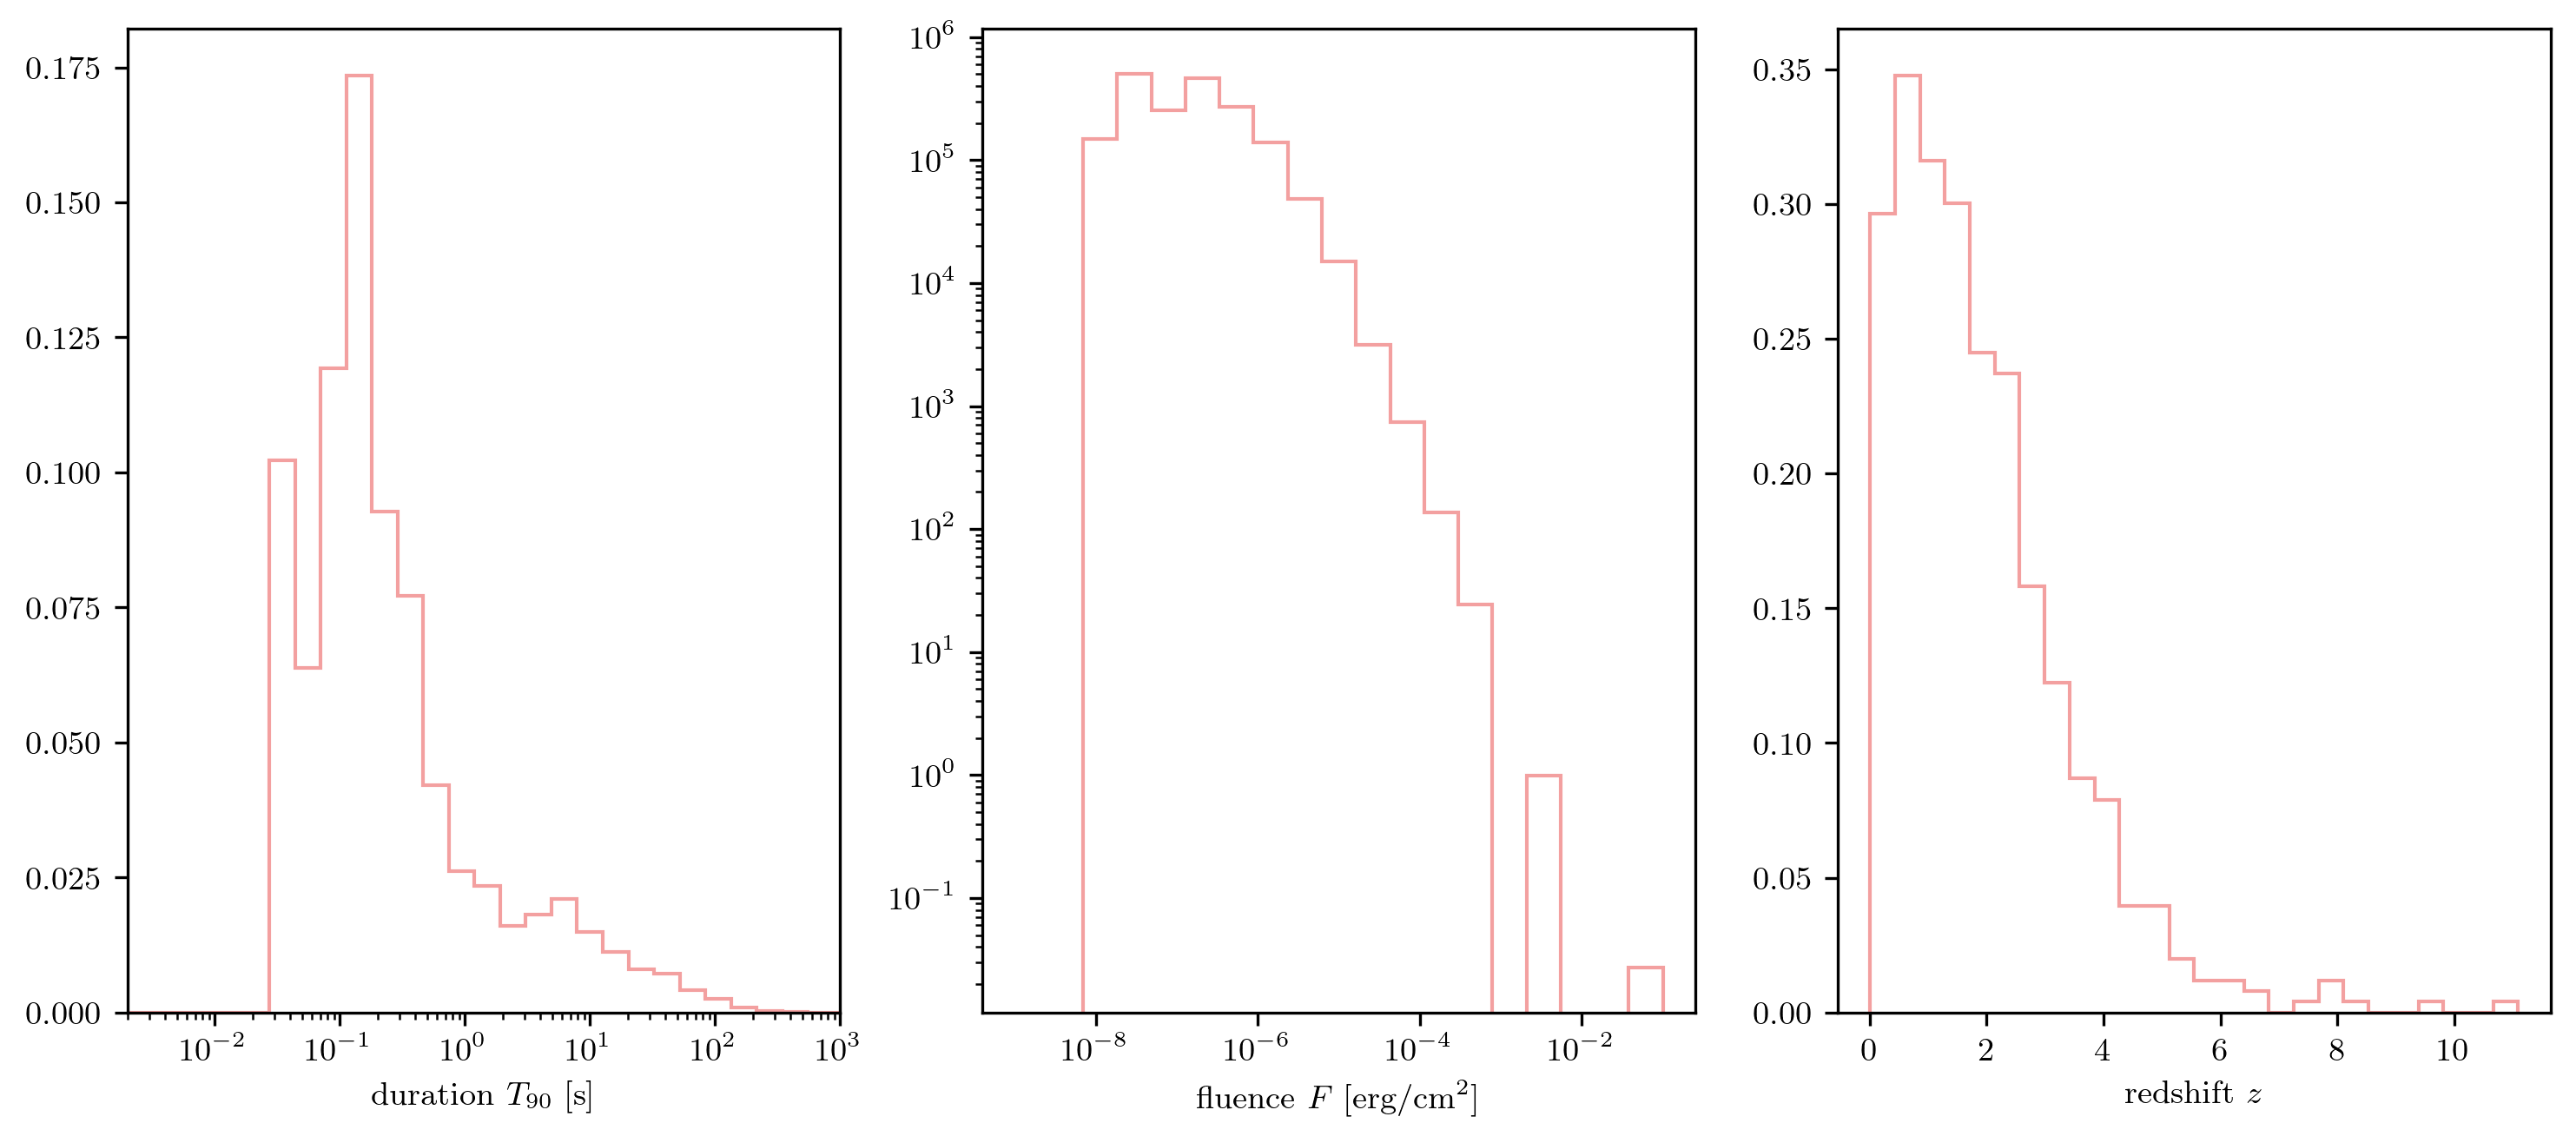

In [130]:
#-------------------------------------------------------------------------------------------
# Quick look at the data: some histograms
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,5))

#-------------------------------------------------------------------------------------------

ax[0].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
ax[0].set_xlim(2e-3,1e3)
ax[0].set_xscale('log')

logT_min, logT_max = np.log10(np.min(T)) , np.log10(np.max(T))
binsize_freedman = 2 * ( np.quantile(T,0.75) - np.quantile(T,0.25)) / np.cbrt(len(T))
N_freedman = int( ( np.max(T) - np.min(T) ) / binsize_freedman)

_ = fancyhist(T, ax=ax[0], bins=np.logspace(-3,5,40), histtype="step",density=True, alpha=0.75, color='lightcoral')

# PDF_T_KDE, T_KDE = KDE_sklearn(T,bandwidth=0.5,kernel="epanechnikov")
# ax[0].plot(T_KDE, PDF_T_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[1].set_xlabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[1].set_xscale('log')
ax[1].set_yscale('log')

_ = fancyhist(F, ax=ax[1], bins=np.logspace(-9,-1,20), histtype="step",density=True, alpha=0.75, color='lightcoral')

# PDF_F_KDE, F_KDE = KDE_sklearn(F,bandwidth=1e-3,kernel="epanechnikov")
# ax[1].plot(F_KDE, PDF_F_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[2].set_xlabel(r"redshift $z$")

_ = fancyhist(z, ax=ax[2], bins='freedman', histtype="step",density=True, alpha=0.75, color='lightcoral')


# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

# _ = ax[0].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_histograms.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_histograms.pdf', bbox_inches='tight')


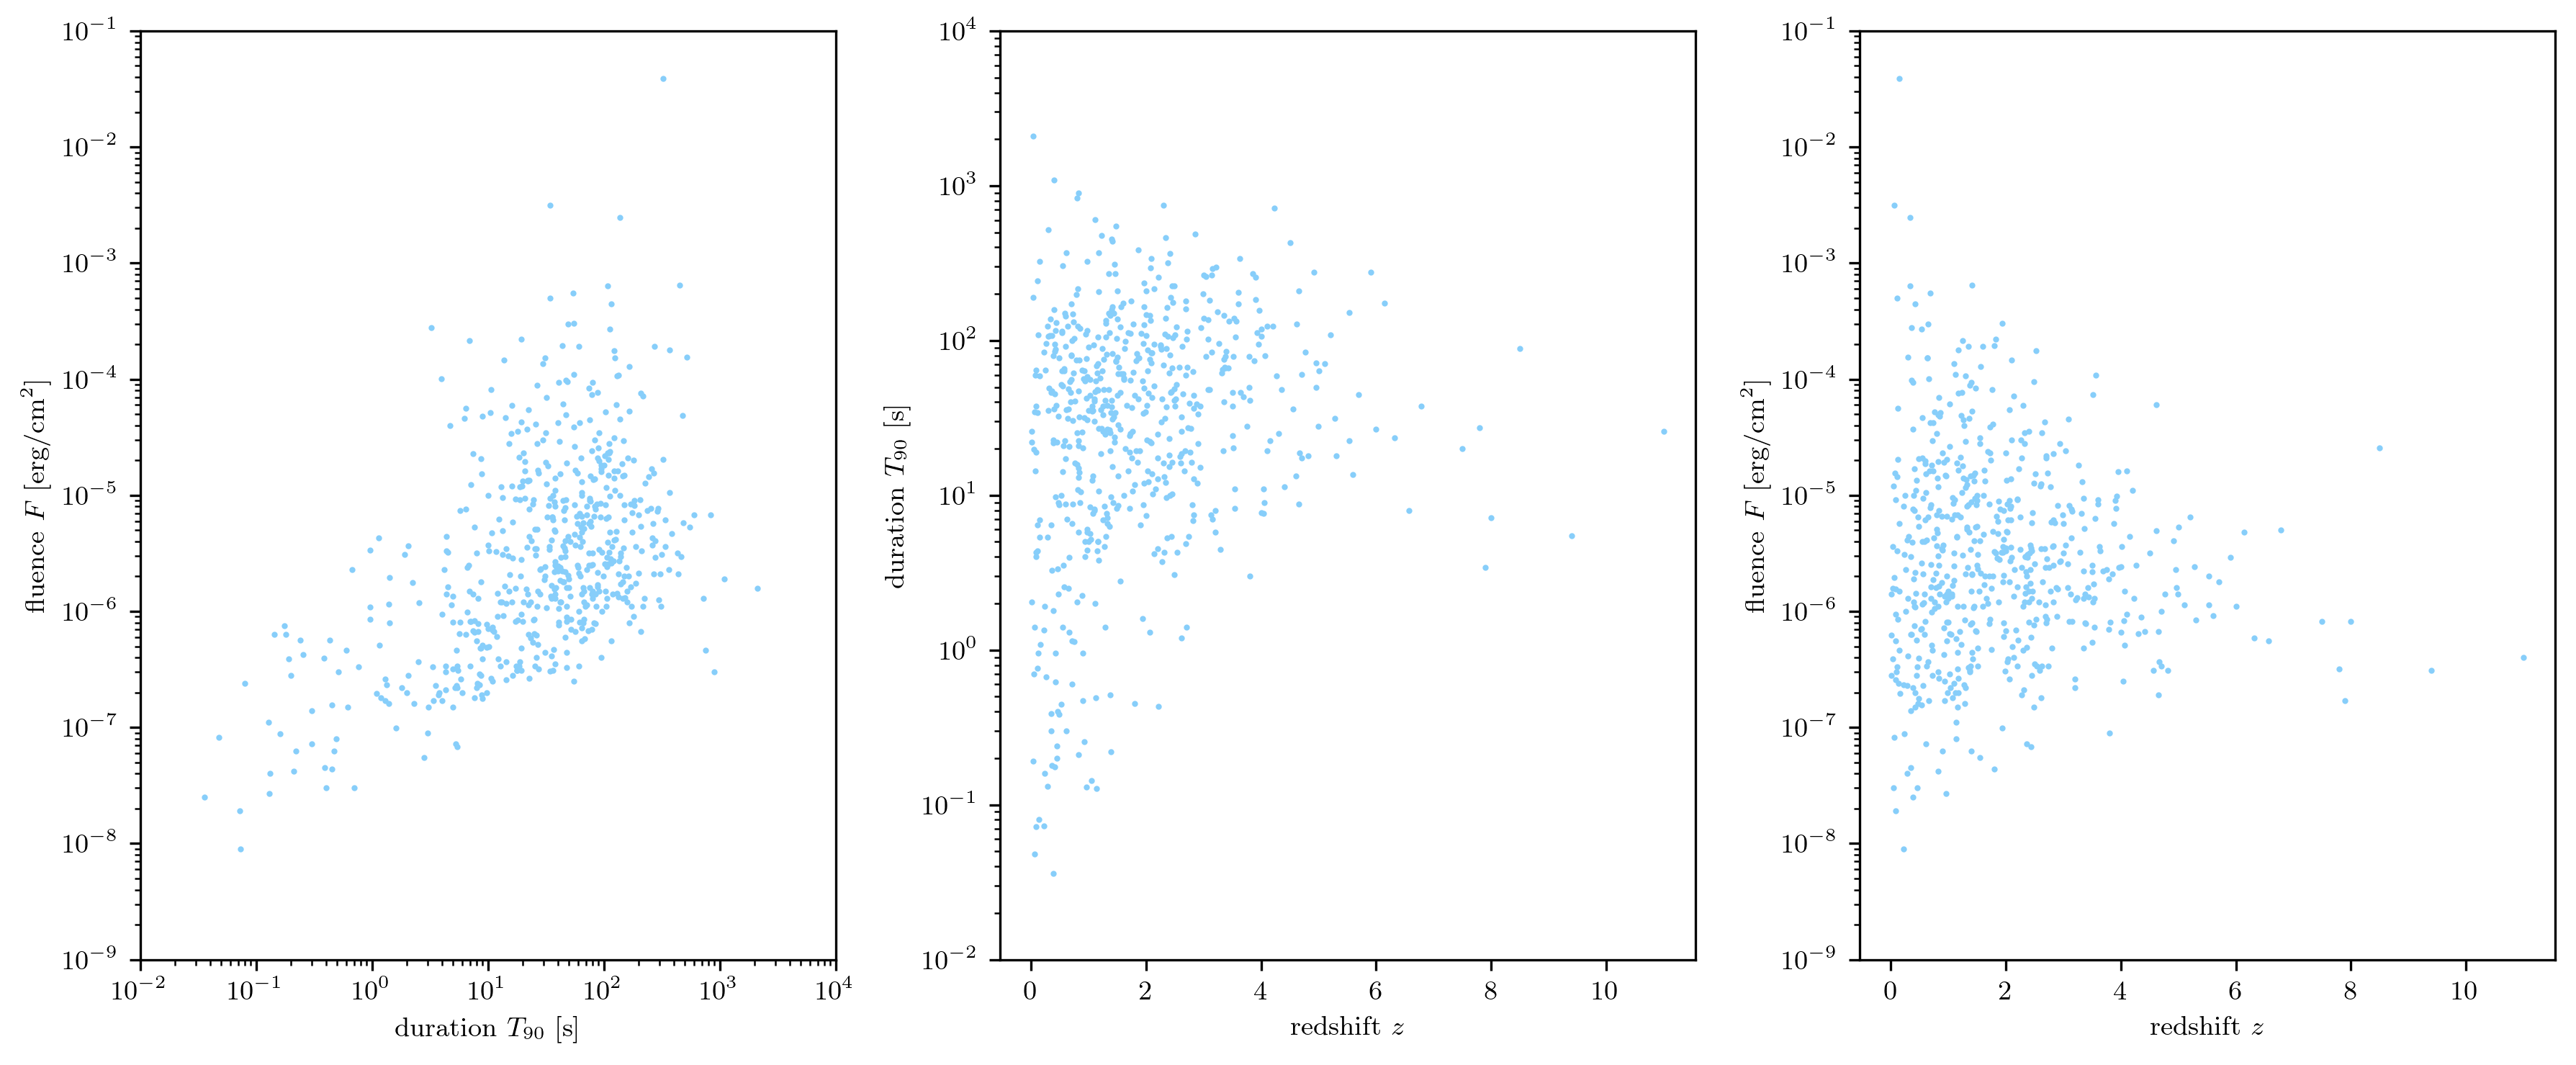

In [131]:
#-------------------------------------------------------------------------------------------
# first look at the data: plots (T-F), (z,T), (z,F)
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,5))

#-------------------------------------------------------------------------------------------

ax[0].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
ax[0].set_xlim(1e-2,1e4)
ax[0].set_xscale('log')
ax[0].set_ylabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[0].set_ylim(1e-9,1e-1)
ax[0].set_yscale('log')
ax[0].scatter(T, F, c='lightskyblue',s=1)

#-------------------------------------------------------------------------------------------

ax[1].set_xlabel(r"redshift $z$")
ax[1].set_ylabel(r"duration $T_{90} \; [\textup{s}]$")
ax[1].set_ylim(1e-2,1e4)
ax[1].set_yscale('log')

ax[1].scatter(z, T, c='lightskyblue',s=1)

# PDF_F_KDE, F_KDE = KDE_sklearn(F,bandwidth=1e-3,kernel="epanechnikov")
# ax[1].plot(F_KDE, PDF_F_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[2].set_xlabel(r"redshift $z$")
ax[2].set_ylabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[2].set_ylim(1e-9,1e-1)
ax[2].set_yscale('log')


ax[2].scatter(z, F, c='lightskyblue',s=1)


# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

if False:
    for i in range(3):
        _ = ax[i].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

fig.tight_layout()

# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_plots.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_plots.pdf', bbox_inches='tight')


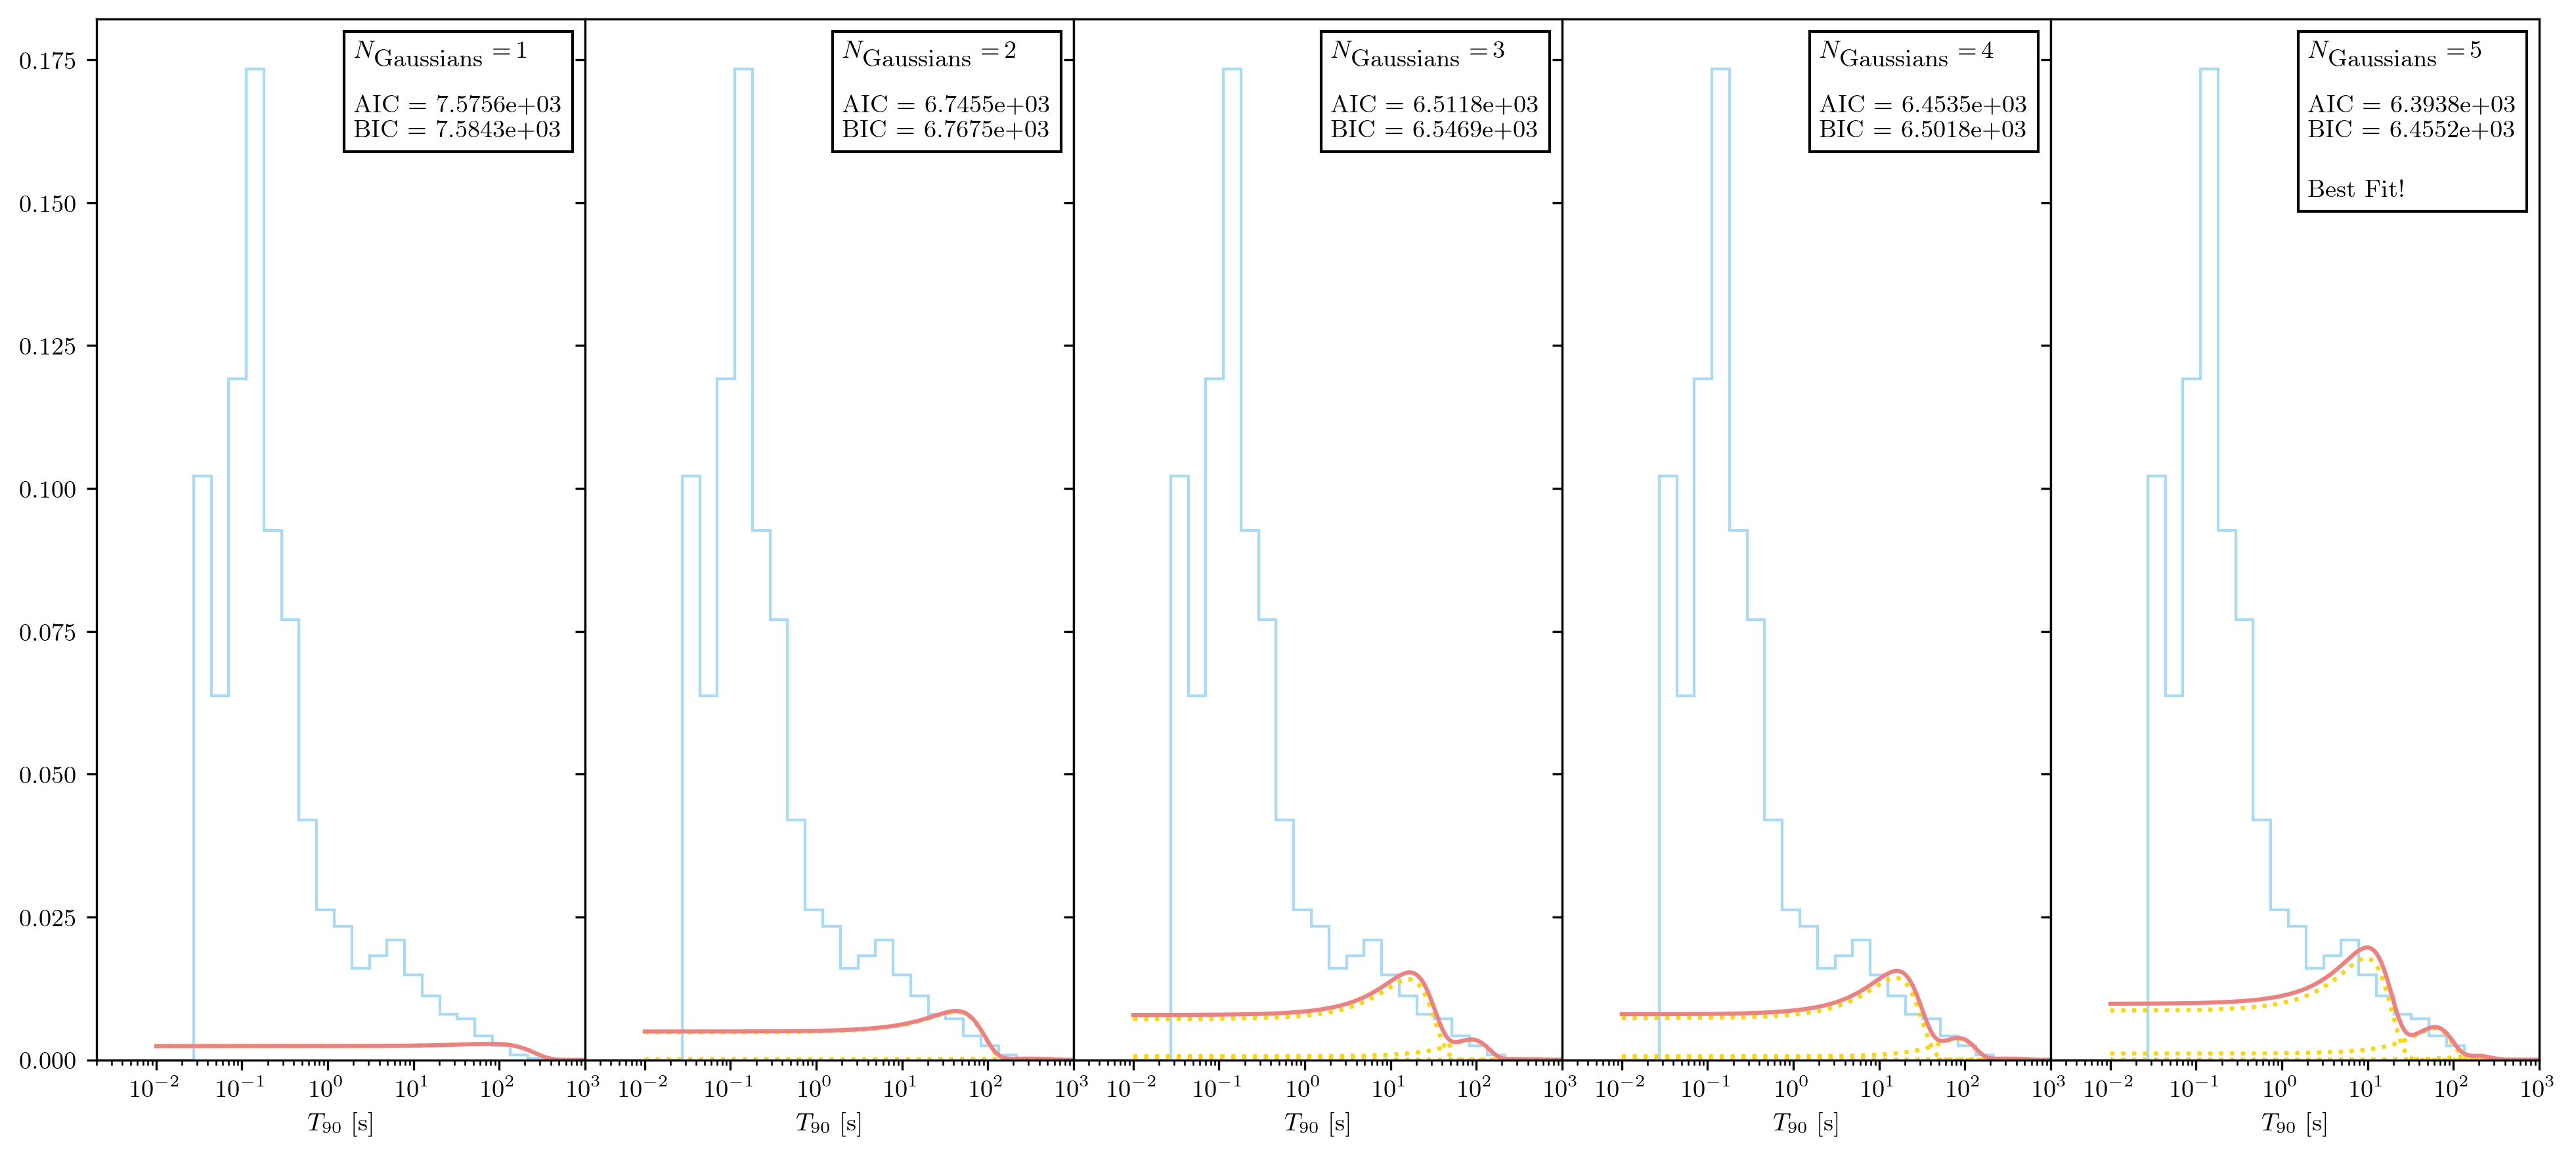

In [120]:
fig , ax = plt.subplots(1,5,figsize=(16,7))
ax = ax.reshape(5)
fig.subplots_adjust(wspace=0.0,hspace=0.0)

# plot the histogram with data 
for n in range(5):
    ax[n].set_xlim(2e-3,1e3)
    ax[n].set_xscale('log')
    _ = fancyhist(T, ax=ax[n], bins=np.logspace(-3,5,40), histtype="step",density=True, alpha=0.75, color='lightskyblue')

# Models, information criteria
Gaussian_Mixture_n, AIC_n , BIC_n = [] , [], []

# Parameters of the individual Gaussian components of each model
Weights_n_i , Means_n_i , Stddevs_n_i = [[] for n in range(5)] , [[] for n in range(5)] , [[] for n in range(5)]

x = np.logspace(-2, 5, 10000)

# With scikit-learn: Gaussian Mixtures with N = 1,2,...,5. 
# Each is done 25 times to (hopefully) not find a local maximum of the Likelihood

for n in range(5):
    Gaussian_Mixture_n.append( GaussianMixture(n_components=n+1, n_init=25).fit(T.reshape(-1,1)) )
    weights_n_Gaussians = Gaussian_Mixture_n[n].weights_ 
    means_n_Gaussians   = Gaussian_Mixture_n[n].means_ 
    covars_n_Gaussians  = Gaussian_Mixture_n[n].covariances_ 
    for i in range(n+1):
        Weights_n_i[n].append( weights_n_Gaussians[i] )
        Means_n_i[n].append( means_n_Gaussians[i][0] )
        Stddevs_n_i[n].append( covars_n_Gaussians[i][0][0]**0.5 )

    # for this model with n components,
    # compute the total pdf which is a sum of the Gaussian components
    logpdf_n = Gaussian_Mixture_n[n].score_samples(x.reshape(-1,1))
    pdf_n    = np.exp(logpdf_n)
    # the individual Gaussian components 
    responsibility_n_i = Gaussian_Mixture_n[n].predict_proba(x.reshape(-1,1)) 
    Gaussian_component_i_of_n = responsibility_n_i * pdf_n[:,np.newaxis]

    # method to evaluate fit goodness:
    aic = Gaussian_Mixture_n[n].aic(T.reshape(-1,1))
    AIC_n.append(aic)    
    aic_label = r'$N_{\textup{Gaussians}}=\,$' + '{:d}'.format(n+1) + '\n\n' + 'AIC = {:.4e}'.format(aic)
    bic = Gaussian_Mixture_n[n].bic(T.reshape(-1,1))
    BIC_n.append(bic)    
    bic_label = '\n' + 'BIC = {:.4e}'.format(bic)
    
    # plot the individual components of the Mixtures:
    for i in range(n+1):
        ax[n].plot( x, Gaussian_component_i_of_n[:,i], color='gold', ls=':')

    # plot the reconstructed best fit pdfs for each Gaussian Mixture
    ax[n].plot( x, pdf_n, color='lightcoral', label=aic_label+bic_label)    
    
# find best Gaussian Mixture with the minimum of the AIC estimator, add it to the plot label:
k = np.argmin(AIC_n)
ax[k].plot( 0, 0, ls='', marker='', label='\nBest Fit!')

    
# --------------------------------------------------------------------------------------
# Utility: legend, adjusting labels, saving the figure...

for n in range(5):
    ax[n].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', handlelength=0, handletextpad=0)
for j in [1,2,3,4]:
    ax[j].tick_params(labelleft=False)
for j in range(5):
    ax[j].set_xlabel(r"$T_{90} \; [\textup{s}]$")

# do we want to save the figure?
if False:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_Mixtura.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_Mixtura.pdf', bbox_inches='tight')
